# Import library

In [80]:
import pandas as pd
import numpy as np
import psycopg2
from sklearn.ensemble import IsolationForest
import joblib
import os

# Database configuration

In [81]:
DB_CONFIG = {
    'host': 'localhost',
    'port': 5432,
    'dbname': 'metrics_db',
    'user': 'mlops',
    'password': 'mlops123'
}

# Loading data

In [82]:
conn = psycopg2.connect(**DB_CONFIG)

df = pd.read_sql(
    "SELECT DISTINCT metric_name FROM metrics",
    con=conn
)

metric_names_list: np.ndarray = df['metric_name'].unique()
metric_names_list

C:\Users\Nguyen Quoc Duong\AppData\Local\Temp\ipykernel_26324\1814025524.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


array(['disk_used_percent', 'net_bytes_recv', 'net_err_out', 'net_err_in',
       'mem_used_percent', 'cpu_usage_active', 'net_bytes_sent'],
      dtype=object)

In [83]:
df = pd.read_sql(
    "SELECT * FROM metrics",
    con=conn
)
df.head(20)

C:\Users\Nguyen Quoc Duong\AppData\Local\Temp\ipykernel_26324\654002547.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


,id,ts,host_id,metric_name,value
0,186421,2026-07-31 06:49:00+00:00,intern-metrics-server-1,mem_used_percent,1.617978e+01
1,186422,2026-07-31 06:49:00+00:00,intern-metrics-server-1,net_bytes_recv,1.785760e+07
2,186423,2026-07-31 06:49:00+00:00,intern-metrics-server-1,net_bytes_sent,2.135908e+07
3,186424,2026-07-31 06:49:00+00:00,intern-metrics-server-1,net_err_in,0.000000e+00
4,186425,2026-07-31 06:49:00+00:00,intern-metrics-server-1,net_err_out,0.000000e+00
5,186426,2026-07-31 06:49:00+00:00,intern-metrics-server-1,disk_used_percent,9.038122e+00
6,186427,2026-07-31 06:49:10+00:00,intern-metrics-server-1,cpu_usage_active,1.005025e+00
7,186428,2026-07-31 06:49:30+00:00,intern-metrics-server-1,cpu_usage_active,1.129518e+00
8,186429,2026-07-31 06:49:30+00:00,intern-metrics-server-1,disk_used_percent,9.038162e+00
9,186430,2026-07-31 06:49:30+00:00,intern-metrics-server-1,net_bytes_recv,1.789242e+07


In [84]:
len(df)

8177

# Visualize data

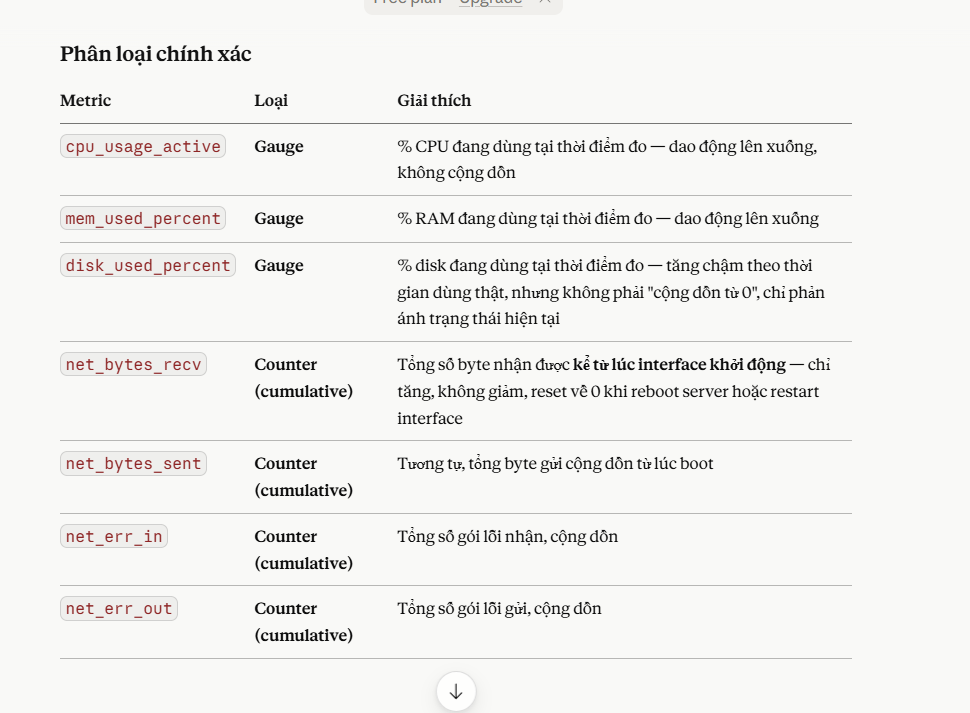

In [85]:
dfs = {metric: group for metric, group in df.groupby('metric_name')}

# tỉ lệ % mà CPU làm việc so với thời gian rảnh
df_cpu: pd.DataFrame = dfs['cpu_usage_active']

# tỉ lệ % lưu trữ trên ổ / mà bị chiếm dụng
df_disk = dfs['disk_used_percent']

# ram còn trống bao nhiêu %
df_mem = dfs['mem_used_percent']

df_network_byte_received = dfs['net_bytes_recv']
df_network_byte_sent = dfs['net_bytes_sent']

# tổng số gói tin card mạng nhận được nhưng gặp lỗi
df_net_err_in = dfs['net_err_in']
# tổng số gói tin mà server gửi đi nhưng bị lỗi
df_net_err_out = dfs['net_err_out']

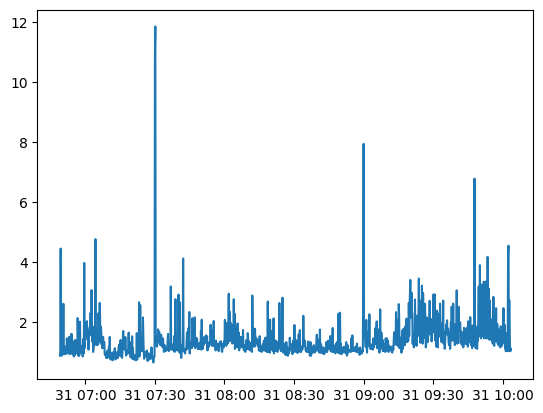

In [86]:
import matplotlib.pyplot as plt

df_cpu = df_cpu.sort_values('ts')

plt.plot(
    df_cpu['ts'],
    df_cpu['value'],
)

plt.show()

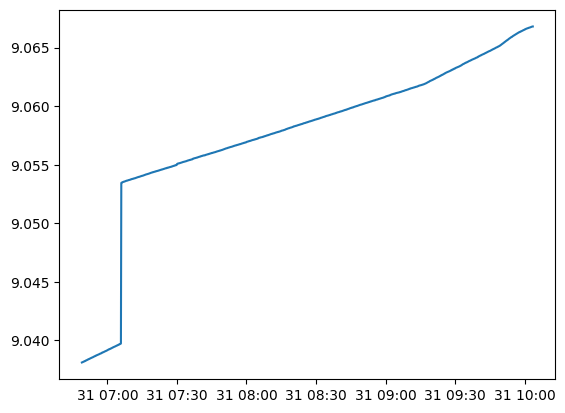

In [87]:
df_disk = df_disk.sort_values('ts')

plt.plot(
    df_disk['ts'],
    df_disk['value'],
)

plt.show()

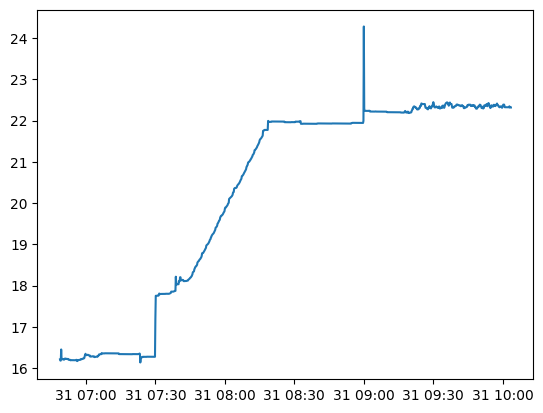

In [88]:
df_mem = df_mem.sort_values('ts')

plt.plot(
    df_mem['ts'],
    df_mem['value'],
)

plt.show()

## Network bytes receieved

Dữ liệu dạng accumulated → tính diff

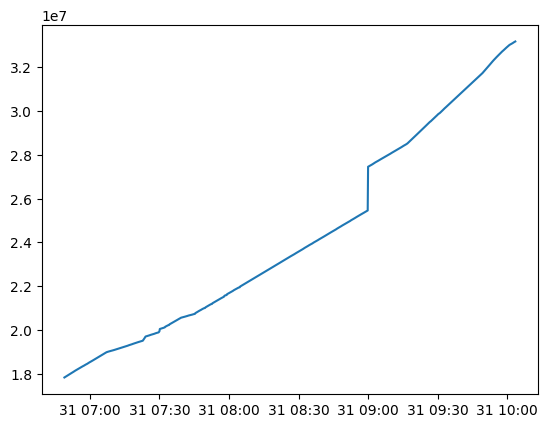

In [89]:
df_network_byte_received = df_network_byte_received.sort_values('ts')

plt.plot(
    df_network_byte_received['ts'],
    df_network_byte_received['value'],
)

plt.show()

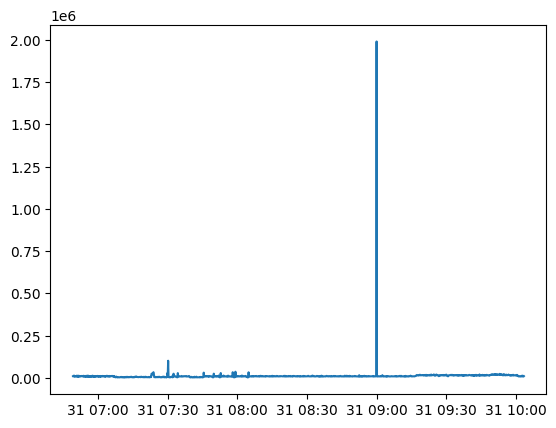

In [90]:
df_network_byte_received['bytes_per_interval'] = df_network_byte_received['value'].diff()

plt.plot(
    df_network_byte_received['ts'], 
    df_network_byte_received['bytes_per_interval']
)

## Network bytes sent

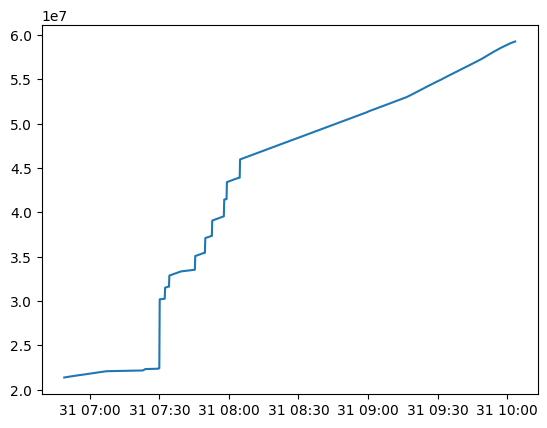

In [91]:
df_network_byte_sent = df_network_byte_sent.sort_values('ts')

plt.plot(
    df_network_byte_sent['ts'],
    df_network_byte_sent['value'],
)

plt.show()

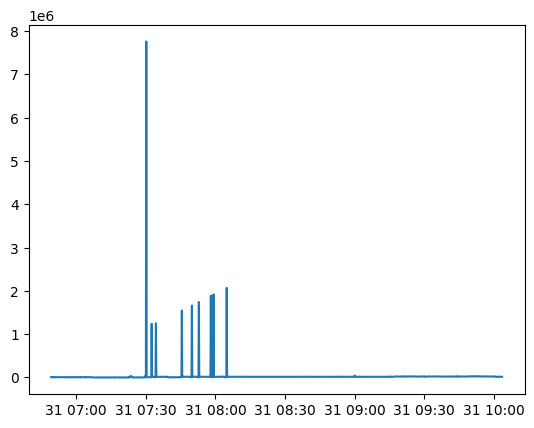

In [92]:
df_network_byte_sent['bytes_per_interval'] = df_network_byte_sent['value'].diff()

plt.plot(
    df_network_byte_sent['ts'], 
    df_network_byte_sent['bytes_per_interval']
)

## Number of error in

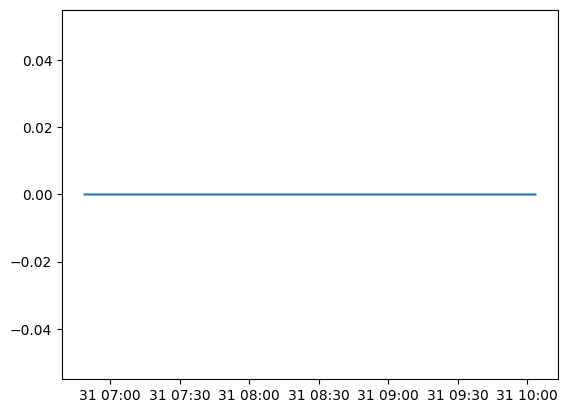

In [93]:
df_net_err_in = df_net_err_in.sort_values('ts')

plt.plot(
    df_net_err_in['ts'],
    df_net_err_in['value'],
)

plt.show()

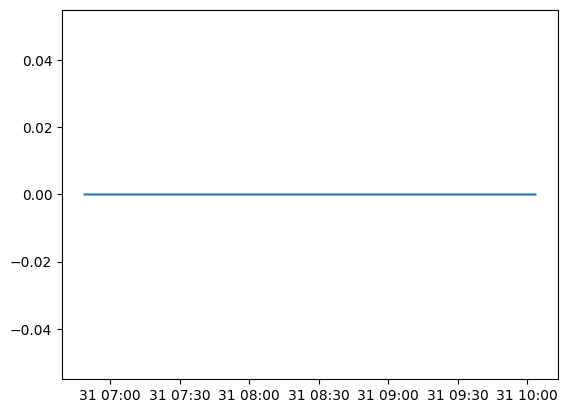

In [94]:
df_net_err_out = df_net_err_out.sort_values('ts')

plt.plot(
    df_net_err_out['ts'],
    df_net_err_out['value'],
)

plt.show()

# Train and evaluation

In [100]:
def build_features(df: pd.DataFrame, window=12) -> pd.DataFrame:
    """
    Sử dụng Rolling mean/std làm feature
    """
    # rolling: (với window=12)
    # giá trị dòng hiện tại được tính dựa trên dòng đó + 11 dòng trước đó
    # với mean: dòng đầu tiên có giá trị bằng chính dòng đó, dòng thứ 2 la fmean của 2 dòng đầu
    # với std: dòng đầu tiên ko tính được vì pandas cần tối thiểu 2 giá trị để tính standard deviation
    df['roll_mean'] = df['value'].rolling(window, min_periods=1).mean()
    df['roll_std']  = df['value'].rolling(window, min_periods=1).std().fillna(0)
    # hàm diff tính toán thay đổi của dòng này với dòng trước đó
    df['diff']      = df['value'].diff().fillna(0)
    return df        

### Isolation Forest: CPU

In [101]:
df_cpu = build_features(df=df_cpu)

In [105]:
df_cpu.head(20)

,id,ts,host_id,metric_name,value,roll_mean,roll_std,diff
1050,187471,2026-07-31 06:49:00+00:00,intern-metrics-server-1,cpu_usage_active,0.879176,0.879176,0.000000,0.000000e+00
6,186427,2026-07-31 06:49:10+00:00,intern-metrics-server-1,cpu_usage_active,1.005025,0.942101,0.088989,1.258490e-01
2136,188557,2026-07-31 06:49:20+00:00,intern-metrics-server-1,cpu_usage_active,4.450591,2.111597,2.026605,3.445566e+00
7,186428,2026-07-31 06:49:30+00:00,intern-metrics-server-1,cpu_usage_active,1.129518,1.866078,1.726037,-3.321073e+00
13,186434,2026-07-31 06:49:40+00:00,intern-metrics-server-1,cpu_usage_active,1.129518,1.718766,1.530656,1.804779e-11
14,186435,2026-07-31 06:49:50+00:00,intern-metrics-server-1,cpu_usage_active,0.878955,1.578797,1.411337,-2.505628e-01
19,186440,2026-07-31 06:50:00+00:00,intern-metrics-server-1,cpu_usage_active,1.155779,1.518366,1.298252,2.768236e-01
2149,188570,2026-07-31 06:50:10+00:00,intern-metrics-server-1,cpu_usage_active,1.054746,1.460414,1.213073,-1.010325e-01
1064,187485,2026-07-31 06:50:20+00:00,intern-metrics-server-1,cpu_usage_active,1.005278,1.409843,1.144823,-4.946865e-02
1066,187487,2026-07-31 06:50:30+00:00,intern-metrics-server-1,cpu_usage_active,2.609787,1.529837,1.144107,1.604509e+00


In [104]:
feature_cols = ['value', 'roll_mean', 'roll_std', 'diff']
X = df_cpu[feature_cols]
contamination = 0.00001

cpu_model = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=315
)

cpu_model.fit(X)

,n_estimators,200
,max_samples,'auto'
,contamination,1e-05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,315
,verbose,0
,warm_start,False


### Isolation Forest: disk

In [106]:
df_disk.head(10)

,id,ts,host_id,metric_name,value
5,186426,2026-07-31 06:49:00+00:00,intern-metrics-server-1,disk_used_percent,9.038122
1051,187472,2026-07-31 06:49:10+00:00,intern-metrics-server-1,disk_used_percent,9.038135
2135,188556,2026-07-31 06:49:20+00:00,intern-metrics-server-1,disk_used_percent,9.038155
8,186429,2026-07-31 06:49:30+00:00,intern-metrics-server-1,disk_used_percent,9.038162
2138,188559,2026-07-31 06:49:40+00:00,intern-metrics-server-1,disk_used_percent,9.038182
1059,187480,2026-07-31 06:49:50+00:00,intern-metrics-server-1,disk_used_percent,9.038202
2144,188565,2026-07-31 06:50:00+00:00,intern-metrics-server-1,disk_used_percent,9.038209
20,186441,2026-07-31 06:50:10+00:00,intern-metrics-server-1,disk_used_percent,9.038229
2152,188573,2026-07-31 06:50:20+00:00,intern-metrics-server-1,disk_used_percent,9.038249
1065,187486,2026-07-31 06:50:30+00:00,intern-metrics-server-1,disk_used_percent,9.038249


In [109]:
df_disk = build_features(df=df_disk)

feature_cols = ['value', 'roll_mean', 'roll_std', 'diff']
X = df_disk[feature_cols]
contamination = 0.00001

disk_model = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=315
)

disk_model.fit(X)

,n_estimators,200
,max_samples,'auto'
,contamination,1e-05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,315
,verbose,0
,warm_start,False


### Isolation forest: memory

In [108]:
df_mem.head(10)

,id,ts,host_id,metric_name,value
1049,187470,2026-07-31 06:48:50+00:00,intern-metrics-server-1,mem_used_percent,16.208423
0,186421,2026-07-31 06:49:00+00:00,intern-metrics-server-1,mem_used_percent,16.179776
1052,187473,2026-07-31 06:49:10+00:00,intern-metrics-server-1,mem_used_percent,16.179580
2134,188555,2026-07-31 06:49:20+00:00,intern-metrics-server-1,mem_used_percent,16.449067
2137,188558,2026-07-31 06:49:30+00:00,intern-metrics-server-1,mem_used_percent,16.217825
1057,187478,2026-07-31 06:49:40+00:00,intern-metrics-server-1,mem_used_percent,16.217677
1058,187479,2026-07-31 06:49:50+00:00,intern-metrics-server-1,mem_used_percent,16.217529
2143,188564,2026-07-31 06:50:00+00:00,intern-metrics-server-1,mem_used_percent,16.217431
2150,188571,2026-07-31 06:50:10+00:00,intern-metrics-server-1,mem_used_percent,16.204387
2151,188572,2026-07-31 06:50:20+00:00,intern-metrics-server-1,mem_used_percent,16.204190


In [110]:
df_mem = build_features(df=df_mem)

feature_cols = ['value', 'roll_mean', 'roll_std', 'diff']
X = df_mem[feature_cols]
contamination = 0.00001

mem_model = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=315
)

mem_model.fit(X)

,n_estimators,200
,max_samples,'auto'
,contamination,1e-05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,315
,verbose,0
,warm_start,False


### Isolation Forest: network

In [113]:
df_network_byte_sent.head(5)

,id,ts,host_id,metric_name,value,bytes_per_interval
2,186423,2026-07-31 06:49:00+00:00,intern-metrics-server-1,net_bytes_sent,21359083.0,NaN
2131,188552,2026-07-31 06:49:10+00:00,intern-metrics-server-1,net_bytes_sent,21366695.0,7612.0
1054,187475,2026-07-31 06:49:20+00:00,intern-metrics-server-1,net_bytes_sent,21378687.0,11992.0
10,186431,2026-07-31 06:49:30+00:00,intern-metrics-server-1,net_bytes_sent,21384935.0,6248.0
2140,188561,2026-07-31 06:49:40+00:00,intern-metrics-server-1,net_bytes_sent,21393599.0,8664.0


In [114]:
df_network_byte_received.head(5)

,id,ts,host_id,metric_name,value,bytes_per_interval
1,186422,2026-07-31 06:49:00+00:00,intern-metrics-server-1,net_bytes_recv,17857605.0,NaN
2130,188551,2026-07-31 06:49:10+00:00,intern-metrics-server-1,net_bytes_recv,17868879.0,11274.0
1053,187474,2026-07-31 06:49:20+00:00,intern-metrics-server-1,net_bytes_recv,17882014.0,13135.0
9,186430,2026-07-31 06:49:30+00:00,intern-metrics-server-1,net_bytes_recv,17892422.0,10408.0
2139,188560,2026-07-31 06:49:40+00:00,intern-metrics-server-1,net_bytes_recv,17906745.0,14323.0


In [117]:
df_net_err_out.head(5)

,id,ts,host_id,metric_name,value
4,186425,2026-07-31 06:49:00+00:00,intern-metrics-server-1,net_err_out,0.0
2133,188554,2026-07-31 06:49:10+00:00,intern-metrics-server-1,net_err_out,0.0
1056,187477,2026-07-31 06:49:20+00:00,intern-metrics-server-1,net_err_out,0.0
12,186433,2026-07-31 06:49:30+00:00,intern-metrics-server-1,net_err_out,0.0
2142,188563,2026-07-31 06:49:40+00:00,intern-metrics-server-1,net_err_out,0.0


In [118]:
df_net_err_in.head(5)

,id,ts,host_id,metric_name,value
3,186424,2026-07-31 06:49:00+00:00,intern-metrics-server-1,net_err_in,0.0
2132,188553,2026-07-31 06:49:10+00:00,intern-metrics-server-1,net_err_in,0.0
1055,187476,2026-07-31 06:49:20+00:00,intern-metrics-server-1,net_err_in,0.0
11,186432,2026-07-31 06:49:30+00:00,intern-metrics-server-1,net_err_in,0.0
2141,188562,2026-07-31 06:49:40+00:00,intern-metrics-server-1,net_err_in,0.0


In [120]:
df_net_err_in.describe(), df_net_err_out.describe(), df_network_byte_received.describe(), df_network_byte_sent.describe()

(                  id   value
 count    1168.000000  1168.0
 mean   190499.841610     0.0
 std      2372.234575     0.0
 min    186424.000000     0.0
 25%    188407.250000     0.0
 50%    190509.500000     0.0
 75%    192552.750000     0.0
 max    194595.000000     0.0,
                   id   value
 count    1168.000000  1168.0
 mean   190500.841610     0.0
 std      2372.234575     0.0
 min    186425.000000     0.0
 25%    188408.250000     0.0
 50%    190510.500000     0.0
 75%    192553.750000     0.0
 max    194596.000000     0.0,
                   id         value  bytes_per_interval
 count    1168.000000  1.168000e+03        1.167000e+03
 mean   190497.841610  2.431042e+07        1.310060e+04
 std      2372.234575  4.511749e+06        5.812390e+04
 min    186422.000000  1.785760e+07        3.310000e+03
 25%    188405.250000  2.047414e+07        9.310500e+03
 50%    190507.500000  2.335047e+07        1.032600e+04
 75%    192550.750000  2.837326e+07        1.370200e+04
 max    19

In [127]:
df_net_join_1 = pd.merge(df_net_err_in, df_net_err_out, on='ts', how='inner', suffixes=('_err_in', '_err_out'))
df_net_join_1.head(5)

,id_err_in,ts,host_id_err_in,metric_name_err_in,value_err_in,id_err_out,host_id_err_out,metric_name_err_out,value_err_out
0,186424,2026-07-31 06:49:00+00:00,intern-metrics-server-1,net_err_in,0.0,186425,intern-metrics-server-1,net_err_out,0.0
1,188553,2026-07-31 06:49:10+00:00,intern-metrics-server-1,net_err_in,0.0,188554,intern-metrics-server-1,net_err_out,0.0
2,187476,2026-07-31 06:49:20+00:00,intern-metrics-server-1,net_err_in,0.0,187477,intern-metrics-server-1,net_err_out,0.0
3,186432,2026-07-31 06:49:30+00:00,intern-metrics-server-1,net_err_in,0.0,186433,intern-metrics-server-1,net_err_out,0.0
4,188562,2026-07-31 06:49:40+00:00,intern-metrics-server-1,net_err_in,0.0,188563,intern-metrics-server-1,net_err_out,0.0


In [128]:
df_net_join_2 = pd.merge(df_network_byte_sent, df_network_byte_received, on='ts', how='inner', suffixes=('_byte_sent', '_byte_received'))
df_net_join_2.head(5)

,id_byte_sent,ts,host_id_byte_sent,metric_name_byte_sent,value_byte_sent,bytes_per_interval_byte_sent,id_byte_received,host_id_byte_received,metric_name_byte_received,value_byte_received,bytes_per_interval_byte_received
0,186423,2026-07-31 06:49:00+00:00,intern-metrics-server-1,net_bytes_sent,21359083.0,NaN,186422,intern-metrics-server-1,net_bytes_recv,17857605.0,NaN
1,188552,2026-07-31 06:49:10+00:00,intern-metrics-server-1,net_bytes_sent,21366695.0,7612.0,188551,intern-metrics-server-1,net_bytes_recv,17868879.0,11274.0
2,187475,2026-07-31 06:49:20+00:00,intern-metrics-server-1,net_bytes_sent,21378687.0,11992.0,187474,intern-metrics-server-1,net_bytes_recv,17882014.0,13135.0
3,186431,2026-07-31 06:49:30+00:00,intern-metrics-server-1,net_bytes_sent,21384935.0,6248.0,186430,intern-metrics-server-1,net_bytes_recv,17892422.0,10408.0
4,188561,2026-07-31 06:49:40+00:00,intern-metrics-server-1,net_bytes_sent,21393599.0,8664.0,188560,intern-metrics-server-1,net_bytes_recv,17906745.0,14323.0


In [130]:
df_net_join = pd.merge(df_net_join_1, df_net_join_2, on='ts', how='inner')
df_net_join.head()

,id_err_in,ts,host_id_err_in,metric_name_err_in,value_err_in,id_err_out,host_id_err_out,metric_name_err_out,value_err_out,id_byte_sent,host_id_byte_sent,metric_name_byte_sent,value_byte_sent,bytes_per_interval_byte_sent,id_byte_received,host_id_byte_received,metric_name_byte_received,value_byte_received,bytes_per_interval_byte_received
0,186424,2026-07-31 06:49:00+00:00,intern-metrics-server-1,net_err_in,0.0,186425,intern-metrics-server-1,net_err_out,0.0,186423,intern-metrics-server-1,net_bytes_sent,21359083.0,NaN,186422,intern-metrics-server-1,net_bytes_recv,17857605.0,NaN
1,188553,2026-07-31 06:49:10+00:00,intern-metrics-server-1,net_err_in,0.0,188554,intern-metrics-server-1,net_err_out,0.0,188552,intern-metrics-server-1,net_bytes_sent,21366695.0,7612.0,188551,intern-metrics-server-1,net_bytes_recv,17868879.0,11274.0
2,187476,2026-07-31 06:49:20+00:00,intern-metrics-server-1,net_err_in,0.0,187477,intern-metrics-server-1,net_err_out,0.0,187475,intern-metrics-server-1,net_bytes_sent,21378687.0,11992.0,187474,intern-metrics-server-1,net_bytes_recv,17882014.0,13135.0
3,186432,2026-07-31 06:49:30+00:00,intern-metrics-server-1,net_err_in,0.0,186433,intern-metrics-server-1,net_err_out,0.0,186431,intern-metrics-server-1,net_bytes_sent,21384935.0,6248.0,186430,intern-metrics-server-1,net_bytes_recv,17892422.0,10408.0
4,188562,2026-07-31 06:49:40+00:00,intern-metrics-server-1,net_err_in,0.0,188563,intern-metrics-server-1,net_err_out,0.0,188561,intern-metrics-server-1,net_bytes_sent,21393599.0,8664.0,188560,intern-metrics-server-1,net_bytes_recv,17906745.0,14323.0


In [132]:
features = [
    'value_err_in',
    'value_err_out',
    'bytes_per_interval_byte_sent',
    'bytes_per_interval_byte_received',
]

In [133]:
df_net_join.fillna(0)

,id_err_in,ts,host_id_err_in,metric_name_err_in,value_err_in,id_err_out,host_id_err_out,metric_name_err_out,value_err_out,id_byte_sent,host_id_byte_sent,metric_name_byte_sent,value_byte_sent,bytes_per_interval_byte_sent,id_byte_received,host_id_byte_received,metric_name_byte_received,value_byte_received,bytes_per_interval_byte_received
0,186424,2026-07-31 06:49:00+00:00,intern-metrics-server-1,net_err_in,0.0,186425,intern-metrics-server-1,net_err_out,0.0,186423,intern-metrics-server-1,net_bytes_sent,21359083.0,0.0,186422,intern-metrics-server-1,net_bytes_recv,17857605.0,0.0
1,188553,2026-07-31 06:49:10+00:00,intern-metrics-server-1,net_err_in,0.0,188554,intern-metrics-server-1,net_err_out,0.0,188552,intern-metrics-server-1,net_bytes_sent,21366695.0,7612.0,188551,intern-metrics-server-1,net_bytes_recv,17868879.0,11274.0
2,187476,2026-07-31 06:49:20+00:00,intern-metrics-server-1,net_err_in,0.0,187477,intern-metrics-server-1,net_err_out,0.0,187475,intern-metrics-server-1,net_bytes_sent,21378687.0,11992.0,187474,intern-metrics-server-1,net_bytes_recv,17882014.0,13135.0
3,186432,2026-07-31 06:49:30+00:00,intern-metrics-server-1,net_err_in,0.0,186433,intern-metrics-server-1,net_err_out,0.0,186431,intern-metrics-server-1,net_bytes_sent,21384935.0,6248.0,186430,intern-metrics-server-1,net_bytes_recv,17892422.0,10408.0
4,188562,2026-07-31 06:49:40+00:00,intern-metrics-server-1,net_err_in,0.0,188563,intern-metrics-server-1,net_err_out,0.0,188561,intern-metrics-server-1,net_bytes_sent,21393599.0,8664.0,188560,intern-metrics-server-1,net_bytes_recv,17906745.0,14323.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1163,194566,2026-07-31 10:02:50+00:00,intern-metrics-server-1,net_err_in,0.0,194567,intern-metrics-server-1,net_err_out,0.0,194565,intern-metrics-server-1,net_bytes_sent,59199483.0,16249.0,194564,intern-metrics-server-1,net_bytes_recv,33106449.0,14087.0
1164,194575,2026-07-31 10:03:00+00:00,intern-metrics-server-1,net_err_in,0.0,194576,intern-metrics-server-1,net_err_out,0.0,194574,intern-metrics-server-1,net_bytes_sent,59214871.0,15388.0,194573,intern-metrics-server-1,net_bytes_recv,33116317.0,9868.0
1165,194580,2026-07-31 10:03:10+00:00,intern-metrics-server-1,net_err_in,0.0,194581,intern-metrics-server-1,net_err_out,0.0,194579,intern-metrics-server-1,net_bytes_sent,59230557.0,15686.0,194578,intern-metrics-server-1,net_bytes_recv,33125771.0,9454.0
1166,194589,2026-07-31 10:03:20+00:00,intern-metrics-server-1,net_err_in,0.0,194590,intern-metrics-server-1,net_err_out,0.0,194588,intern-metrics-server-1,net_bytes_sent,59246179.0,15622.0,194587,intern-metrics-server-1,net_bytes_recv,33134683.0,8912.0


In [136]:
feature: str

for feature in features:
    feature_name = 'roll_mean_' + feature
    # print(feature_name)
    df[feature_name] = df[feature].rolling(window=12, min_periods=1).mean()

KeyError: 'value_err_in'